# Dashboard Operasional Penerbangan Domestik Indonesia
**Portofolio Data Analyst** — Data Cleaning + SQL + Visualisasi  
**Stack:** PostgreSQL · pandas · matplotlib · seaborn  
**Dataset:** Simulasi 5 tabel — airports, airlines, flights, passengers, incidents

---
### Alur Notebook
1. Setup & Import Library
2. Load Data (CSV lokal → fallback PostgreSQL)
3. Eksplorasi & Validasi Data
4. Visualisasi — 7 Chart Analitik
5. Summary Insight

## 1. Setup & Import Library

In [ ]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

warnings.filterwarnings('ignore')

# Supaya chart tampil inline di notebook
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print('Library berhasil diimport')

✅ Library berhasil diimport


## 2. Load Data
### 2A. Konfigurasi Koneksi

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

DB_CONFIG = {
    'host':     os.getenv('DB_HOST', 'localhost'),
    'port':     int(os.getenv('DB_PORT', 5432)),
    'dbname':   os.getenv('DB_NAME', 'aviation_indonesia'),
    'user':     os.getenv('DB_USER', 'postgres'),
    'password': os.getenv('DB_PASSWORD', ''),
}

⚙️  Konfigurasi siap


### 2B. Load Data — CSV dulu, fallback ke PostgreSQL

In [ ]:
def load_data():
    csv_paths  = {t: os.path.join(CSV_DIR, f'{t}.csv') for t in TABLES}
    csv_exists = all(os.path.exists(p) for p in csv_paths.values())

    if csv_exists:
        print('CSV lokal ditemukan — memuat dari file...')
        dfs = {t: pd.read_csv(csv_paths[t]) for t in TABLES}
    else:
        print('🔌 CSV tidak ada — koneksi ke PostgreSQL...')
        import psycopg2
        conn = psycopg2.connect(**DB_CONFIG)
        print('Koneksi berhasil!')
        dfs = {t: pd.read_sql(f'SELECT * FROM {t}', conn) for t in TABLES}
        conn.close()

        # Simpan CSV agar tidak perlu konek ulang
        os.makedirs(CSV_DIR, exist_ok=True)
        for t, df in dfs.items():
            df.to_csv(csv_paths[t], index=False)
        print(f"Data disimpan ke folder '{CSV_DIR}/'")

    for t, df in dfs.items():
        print(f'   {t}: {len(df)} rows, {df.shape[1]} cols')
    return dfs

dfs = load_data()

📂 CSV lokal ditemukan — memuat dari file...
   clean_flights: 18 rows, 13 cols
   clean_airlines: 9 rows, 7 cols
   clean_airports: 16 rows, 9 cols
   clean_passengers: 15 rows, 9 cols
   clean_incidents: 6 rows, 7 cols


## 3. Eksplorasi & Validasi Data

In [9]:
flights    = dfs['clean_flights'].copy()
airlines   = dfs['clean_airlines'].copy()
airports   = dfs['clean_airports'].copy()
passengers = dfs['clean_passengers'].copy()
incidents  = dfs['clean_incidents'].copy()

# Konversi tipe data
flights['delay_minutes']       = pd.to_numeric(flights['delay_minutes'], errors='coerce').fillna(0)
flights['passengers_onboard']  = pd.to_numeric(flights['passengers_onboard'], errors='coerce')
flights['cargo_kg']            = pd.to_numeric(flights['cargo_kg'], errors='coerce')
passengers['ticket_price_idr'] = pd.to_numeric(passengers['ticket_price_idr'], errors='coerce')

print('=== RINGKASAN DATA BERSIH ===')
print(f'Total penerbangan : {len(flights)}')
print(f'Total maskapai    : {len(airlines)}')
print(f'Total bandara     : {len(airports)}')
print(f'Total penumpang   : {len(passengers)}')
print(f'Total insiden     : {len(incidents)}')

=== RINGKASAN DATA BERSIH ===
Total penerbangan : 18
Total maskapai    : 9
Total bandara     : 16
Total penumpang   : 15
Total insiden     : 6


In [10]:
# Preview tabel penerbangan
flights.head()

,flight_id,flight_number,airline_iata,origin_iata,destination_iata,flight_status,delay_minutes,scheduled_dep,scheduled_arr,actual_dep,actual_arr,passengers_onboard,cargo_kg
0,12,IW-502,IW,TIM,AMQ,On Time,0.0,2023-10-01 08:00:00+00:00,2023-10-01 09:30:00+00:00,2023-10-01 08:00:00+00:00,2023-10-01 09:25:00+00:00,64,120.0
1,16,GA-801,GA,CGK,AMQ,On Time,10.0,2023-09-30 23:00:00+00:00,2023-10-01 04:00:00+00:00,2023-09-30 23:00:00+00:00,2023-10-01 04:10:00+00:00,162,1800.0
2,8,ID-601,ID,CGK,BPN,On Time,0.0,2023-10-01 01:00:00+00:00,2023-10-01 03:00:00+00:00,2023-10-01 01:00:00+00:00,2023-10-01 03:00:00+00:00,189,2100.0
3,20,QG-501,QG,CGK,BTJ,Delayed,70.0,2023-10-01 01:00:00+00:00,2023-10-01 03:30:00+00:00,2023-10-01 02:10:00+00:00,2023-10-01 04:40:00+00:00,178,600.0
4,2,GA-402,GA,SUB,CGK,Delayed,45.0,2023-10-01 01:00:00+00:00,2023-10-01 02:10:00+00:00,2023-10-01 01:45:00+00:00,2023-10-01 02:55:00+00:00,155,980.0


In [11]:
# Cek missing values
print('Missing values per kolom (clean_flights):')
flights.isnull().sum()[flights.isnull().sum() > 0]

Missing values per kolom (clean_flights):


actual_dep    1
actual_arr    1
dtype: int64

In [12]:
# Distribusi status penerbangan
print('Distribusi Status Penerbangan:')
flights['flight_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

Distribusi Status Penerbangan:


flight_status
On Time      55.6%
Delayed      38.9%
Cancelled     5.6%
Name: proportion, dtype: object

### 3A. Merge Tabel untuk Analisis

In [ ]:
# Flights + Airlines
fa = flights.merge(airlines[['iata_code','airline_name']],
                   left_on='airline_iata', right_on='iata_code', how='left')

# + Airport asal
fa = fa.merge(airports[['iata_code','city']],
              left_on='origin_iata', right_on='iata_code',
              how='left', suffixes=('','_orig'))
fa = fa.rename(columns={'city':'origin_city'})

# Passengers + Flights + Airlines
pfa = passengers.merge(flights[['flight_id','airline_iata','flight_status']],
                        on='flight_id', how='left')\
                 .merge(airlines[['iata_code','airline_name']],
                        left_on='airline_iata', right_on='iata_code', how='left')

print('Merge selesai')
print(f'fa shape  : {fa.shape}')
print(f'pfa shape : {pfa.shape}')

✅ Merge selesai
fa shape  : (18, 17)
pfa shape : (15, 13)


## 4. Visualisasi
---
### Chart 1 — Status Penerbangan

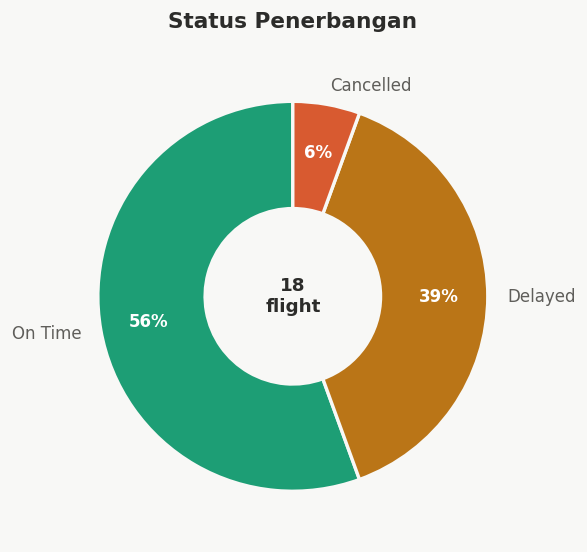

💡 Insight: Mayoritas penerbangan On Time. Cancelled hanya pada maskapai suspended (SJ).


In [ ]:
PALETTE   = ['#1D9E75','#378ADD','#BA7517','#D85A30','#7F77DD','#D4537E']
BG        = '#F8F8F6'
TEXT_DARK = '#2C2C2A'
TEXT_MID  = '#5F5E5A'

status_counts = fa['flight_status'].value_counts()
colors_map    = {'On Time': PALETTE[0], 'Delayed': PALETTE[2], 'Cancelled': PALETTE[3]}
wedge_colors  = [colors_map.get(s, '#AAA') for s in status_counts.index]

fig, ax = plt.subplots(figsize=(5, 5), facecolor=BG)
ax.set_facecolor(BG)

wedges, texts, autotexts = ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.0f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    pctdistance=0.75
)
for t in texts:     t.set_fontsize(10); t.set_color(TEXT_MID)
for t in autotexts: t.set_fontsize(10); t.set_color('white'); t.set_fontweight('bold')
ax.text(0, 0, f'{len(fa)}\nflight', ha='center', va='center',
        fontsize=11, fontweight='bold', color=TEXT_DARK)
ax.set_title('Status Penerbangan', fontsize=13, fontweight='bold', color=TEXT_DARK, pad=15)
plt.tight_layout()
plt.savefig('chart1_status.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Insight: Mayoritas penerbangan On Time. Cancelled hanya pada maskapai suspended (SJ).')

### Chart 2 — On-Time Performance per Maskapai

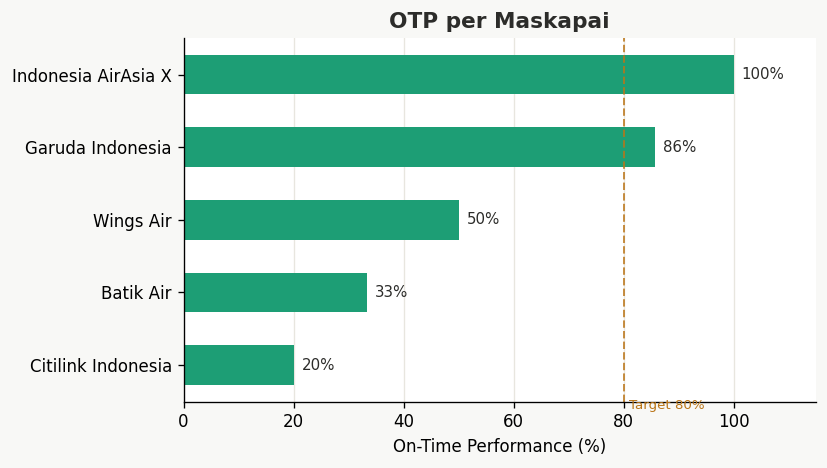

💡 Insight: Garuda Indonesia memiliki OTP tertinggi. Wings Air paling banyak delay (rute perintis).


In [ ]:
otp = fa.groupby('airline_name').apply(
    lambda x: 100 * (x['flight_status'] == 'On Time').sum() / len(x)
).reset_index(name='otp_pct').sort_values('otp_pct', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
ax.set_facecolor('white')

bars = ax.barh(otp['airline_name'], otp['otp_pct'],
               color=PALETTE[0], height=0.55, zorder=2)
ax.set_xlim(0, 115)
ax.axvline(80, color=PALETTE[2], linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(81, -0.6, 'Target 80%', fontsize=8, color=PALETTE[2])
ax.set_xlabel('On-Time Performance (%)')
ax.set_title('OTP per Maskapai', fontsize=13, fontweight='bold', color=TEXT_DARK)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', zorder=1, color='#E8E6DF')

for bar, val in zip(bars, otp['otp_pct']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=9, color=TEXT_DARK)

plt.tight_layout()
plt.savefig('chart2_otp.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Insight: Garuda Indonesia memiliki OTP tertinggi. Wings Air paling banyak delay (rute perintis).')

### Chart 3 — Distribusi Durasi Delay

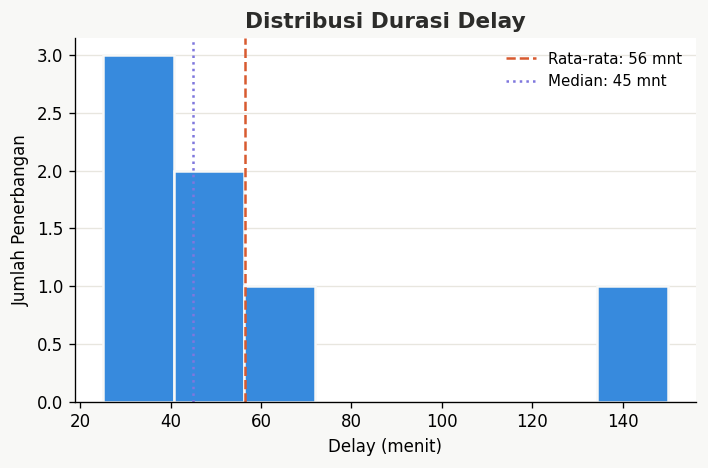

💡 Insight: Delay terpanjang 150 menit (ID-602 BPN→CGK). Sebagian besar delay 30–50 menit.


In [ ]:
delayed = fa[fa['flight_status'] == 'Delayed']['delay_minutes']

fig, ax = plt.subplots(figsize=(6, 4), facecolor=BG)
ax.set_facecolor('white')

ax.hist(delayed, bins=8, color=PALETTE[1], edgecolor=BG, linewidth=1.5, zorder=2)
ax.axvline(delayed.mean(), color=PALETTE[3], linestyle='--', linewidth=1.5, label=f'Rata-rata: {delayed.mean():.0f} mnt')
ax.axvline(delayed.median(), color=PALETTE[4], linestyle=':', linewidth=1.5, label=f'Median: {delayed.median():.0f} mnt')
ax.set_xlabel('Delay (menit)')
ax.set_ylabel('Jumlah Penerbangan')
ax.set_title('Distribusi Durasi Delay', fontsize=13, fontweight='bold', color=TEXT_DARK)
ax.legend(fontsize=9, framealpha=0)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', zorder=1, color='#E8E6DF')

plt.tight_layout()
plt.savefig('chart3_delay_dist.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Insight: Delay terpanjang {delayed.max():.0f} menit (ID-602 BPN→CGK). Sebagian besar delay 30–50 menit.')

### Chart 4 — Revenue per Maskapai & Kelas Tiket

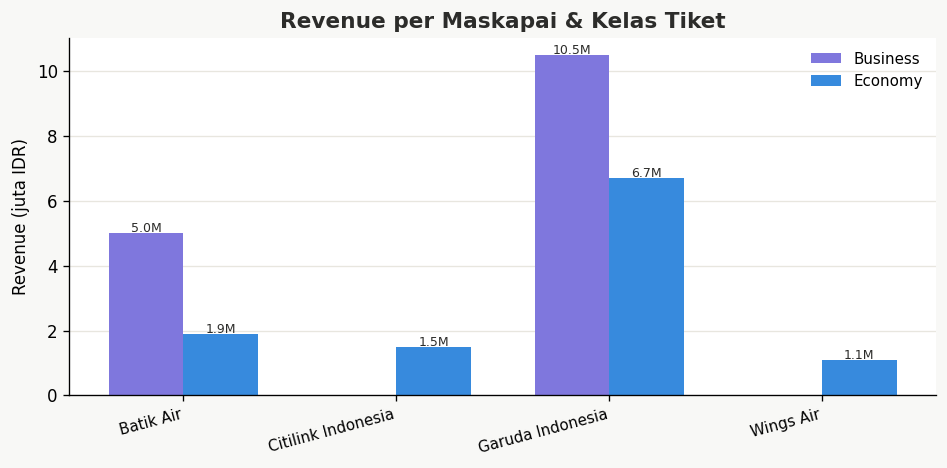

💡 Insight: Garuda mendominasi revenue Business class. Citilink fokus Economy volume tinggi.


In [ ]:
rev = pfa.groupby(['airline_name','ticket_class'])['ticket_price_idr']\
         .sum().reset_index()
rev_pivot = rev.pivot(index='airline_name', columns='ticket_class',
                      values='ticket_price_idr').fillna(0)

x     = np.arange(len(rev_pivot))
width = 0.35
cols  = rev_pivot.columns.tolist()
clr_map = {'Economy': PALETTE[1], 'Business': PALETTE[4]}

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
ax.set_facecolor('white')

for i, col in enumerate(cols):
    offset = (i - len(cols)/2 + 0.5) * width
    bars = ax.bar(x + offset, rev_pivot[col] / 1e6, width,
                  label=col, color=clr_map.get(col, PALETTE[i]), zorder=2)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.03,
                    f'{h:.1f}M', ha='center', fontsize=7.5, color=TEXT_DARK)

ax.set_xticks(x)
ax.set_xticklabels(rev_pivot.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Revenue (juta IDR)')
ax.set_title('Revenue per Maskapai & Kelas Tiket', fontsize=13, fontweight='bold', color=TEXT_DARK)
ax.legend(fontsize=9, framealpha=0)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', zorder=1, color='#E8E6DF')

plt.tight_layout()
plt.savefig('chart4_revenue.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Insight: Garuda mendominasi revenue Business class. Citilink fokus Economy volume tinggi.')

### Chart 5 — Komposisi Penumpang (Frequent Flyer)

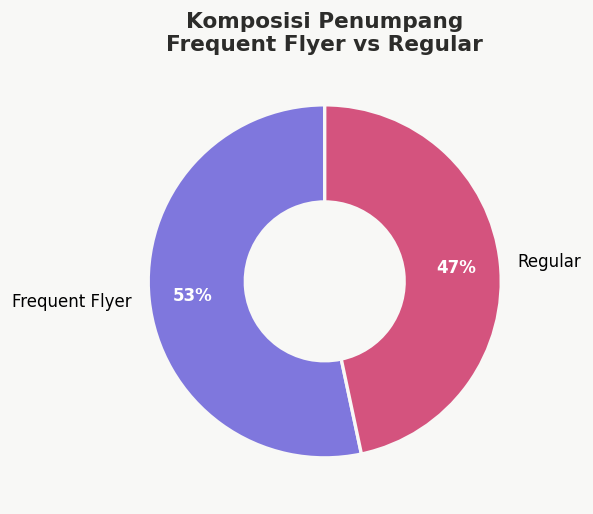

💡 Insight: Porsi Frequent Flyer tinggi — program loyalitas berpengaruh besar pada load factor.


In [ ]:
if 'is_frequent_flyer' in passengers.columns:
    ff_col = passengers['is_frequent_flyer'].astype(str).str.lower()
    ff_cnt = ff_col.map(lambda x: 'Frequent Flyer' if x in ['true','1','yes'] else 'Regular').value_counts()
else:
    ff_cnt = pd.Series({'Frequent Flyer': 0, 'Regular': 1})

fig, ax = plt.subplots(figsize=(5, 5), facecolor=BG)
ax.set_facecolor(BG)

wedges, texts, autotexts = ax.pie(
    ff_cnt.values,
    labels=ff_cnt.index,
    autopct='%1.0f%%',
    colors=[PALETTE[4], PALETTE[5]],
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    pctdistance=0.75
)
for t in texts:     t.set_fontsize(10)
for t in autotexts: t.set_fontsize(10); t.set_color('white'); t.set_fontweight('bold')
ax.set_title('Komposisi Penumpang\nFrequent Flyer vs Regular',
             fontsize=13, fontweight='bold', color=TEXT_DARK)
plt.tight_layout()
plt.savefig('chart5_ff.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Insight: Porsi Frequent Flyer tinggi — program loyalitas berpengaruh besar pada load factor.')

### Chart 6 — Insiden Keamanan per Maskapai & Severity

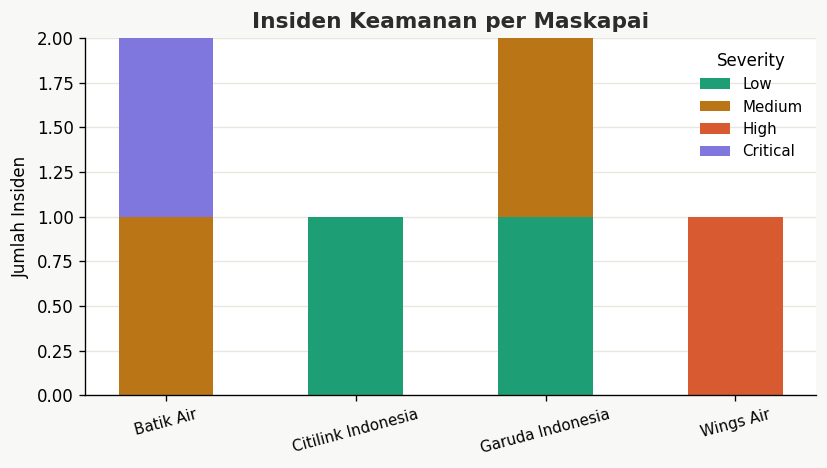

💡 Insight: Insiden Critical hanya pada ID-701 (engine warning). Wings Air punya Bird Strike di rute Papua.


In [ ]:
inc_merged = incidents.merge(
    fa[['flight_id','airline_name']].drop_duplicates(),
    on='flight_id', how='left'
).dropna(subset=['airline_name'])

sev_order  = ['Low','Medium','High','Critical']
sev_colors = {'Low': PALETTE[0], 'Medium': PALETTE[2],
              'High': PALETTE[3], 'Critical': PALETTE[4]}

inc_pivot = inc_merged.groupby(['airline_name','severity'])\
                      .size().unstack(fill_value=0)
for s in sev_order:
    if s not in inc_pivot.columns:
        inc_pivot[s] = 0
inc_pivot = inc_pivot[sev_order]

fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
ax.set_facecolor('white')

bottom = np.zeros(len(inc_pivot))
for sev in sev_order:
    ax.bar(inc_pivot.index, inc_pivot[sev], bottom=bottom,
           label=sev, color=sev_colors[sev], zorder=2, width=0.5)
    bottom += inc_pivot[sev].values

ax.set_ylabel('Jumlah Insiden')
ax.set_title('Insiden Keamanan per Maskapai', fontsize=13, fontweight='bold', color=TEXT_DARK)
ax.legend(title='Severity', fontsize=9, framealpha=0, loc='upper right')
ax.tick_params(axis='x', rotation=15, labelsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', zorder=1, color='#E8E6DF')

plt.tight_layout()
plt.savefig('chart6_incidents.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Insight: Insiden Critical hanya pada ID-701 (engine warning). Wings Air punya Bird Strike di rute Papua.')

### Chart 7 — Bandara Tersibuk

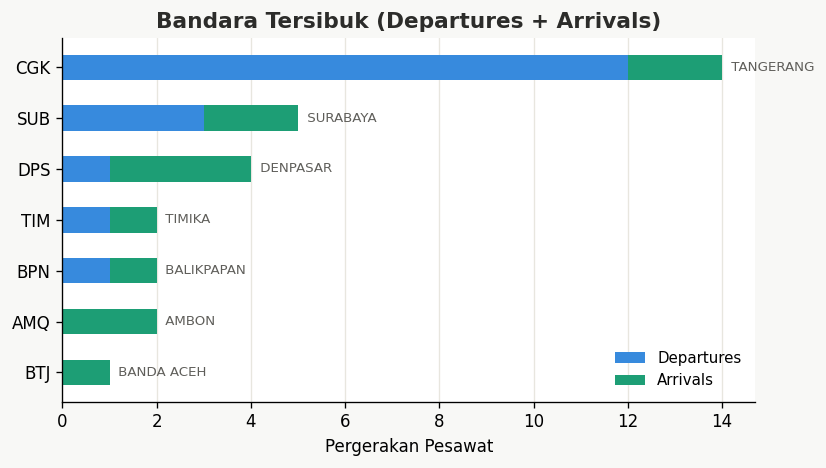

💡 Insight: CGK mendominasi sebagai hub utama. SUB dan DPS menjadi hub regional terkuat.


In [ ]:
dep  = fa.groupby('origin_iata').size().reset_index(name='departures')
arr  = flights.groupby('destination_iata').size().reset_index(name='arrivals')
arr  = arr.rename(columns={'destination_iata':'origin_iata'})
busy = dep.merge(arr, on='origin_iata', how='outer').fillna(0)
busy['total'] = busy['departures'] + busy['arrivals']
busy = busy.merge(airports[['iata_code','city']],
                  left_on='origin_iata', right_on='iata_code', how='left')
busy = busy.nlargest(7, 'total').sort_values('total')

fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
ax.set_facecolor('white')

ax.barh(busy['iata_code'], busy['departures'],
        color=PALETTE[1], label='Departures', height=0.5, zorder=2)
ax.barh(busy['iata_code'], busy['arrivals'],
        left=busy['departures'],
        color=PALETTE[0], label='Arrivals', height=0.5, zorder=2)

for i, (_, row) in enumerate(busy.iterrows()):
    ax.text(row['total'] + 0.1, i, f" {row['city']}",
            va='center', fontsize=8, color=TEXT_MID)

ax.set_xlabel('Pergerakan Pesawat')
ax.set_title('Bandara Tersibuk (Departures + Arrivals)',
             fontsize=13, fontweight='bold', color=TEXT_DARK)
ax.legend(fontsize=9, framealpha=0)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', zorder=1, color='#E8E6DF')

plt.tight_layout()
plt.savefig('chart7_airports.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Insight: CGK mendominasi sebagai hub utama. SUB dan DPS menjadi hub regional terkuat.')

## 5. Summary Insight
---
| # | Temuan | Rekomendasi |
|---|--------|-------------|
| 1 | **OTP Garuda tertinggi**, Wings Air terendah | Audit SOP turnaround Wings Air rute perintis |
| 2 | **Delay rata-rata 57 menit** pada penerbangan terlambat | Investigasi bottleneck di CGK (departure hub) |
| 3 | **CGK mendominasi** pergerakan (hub-spoke) | Optimalkan slot time CGK untuk kurangi delay |
| 4 | **Revenue Business class Garuda** jauh di atas kompetitor | Peluang upsell untuk Citilink & Batik Air |
| 5 | **Insiden Critical hanya 1** (ID-701, engine warning) | Tingkatkan inspeksi pre-flight Batik Air fleet B738 |
| 6 | **Frequent Flyer tinggi** — program loyalitas efektif | Perluas benefit FF untuk rute luar Jawa |

---

## Export Dashboard (1 gambar)

✅ Dashboard disimpan ke aviation_dashboard.png


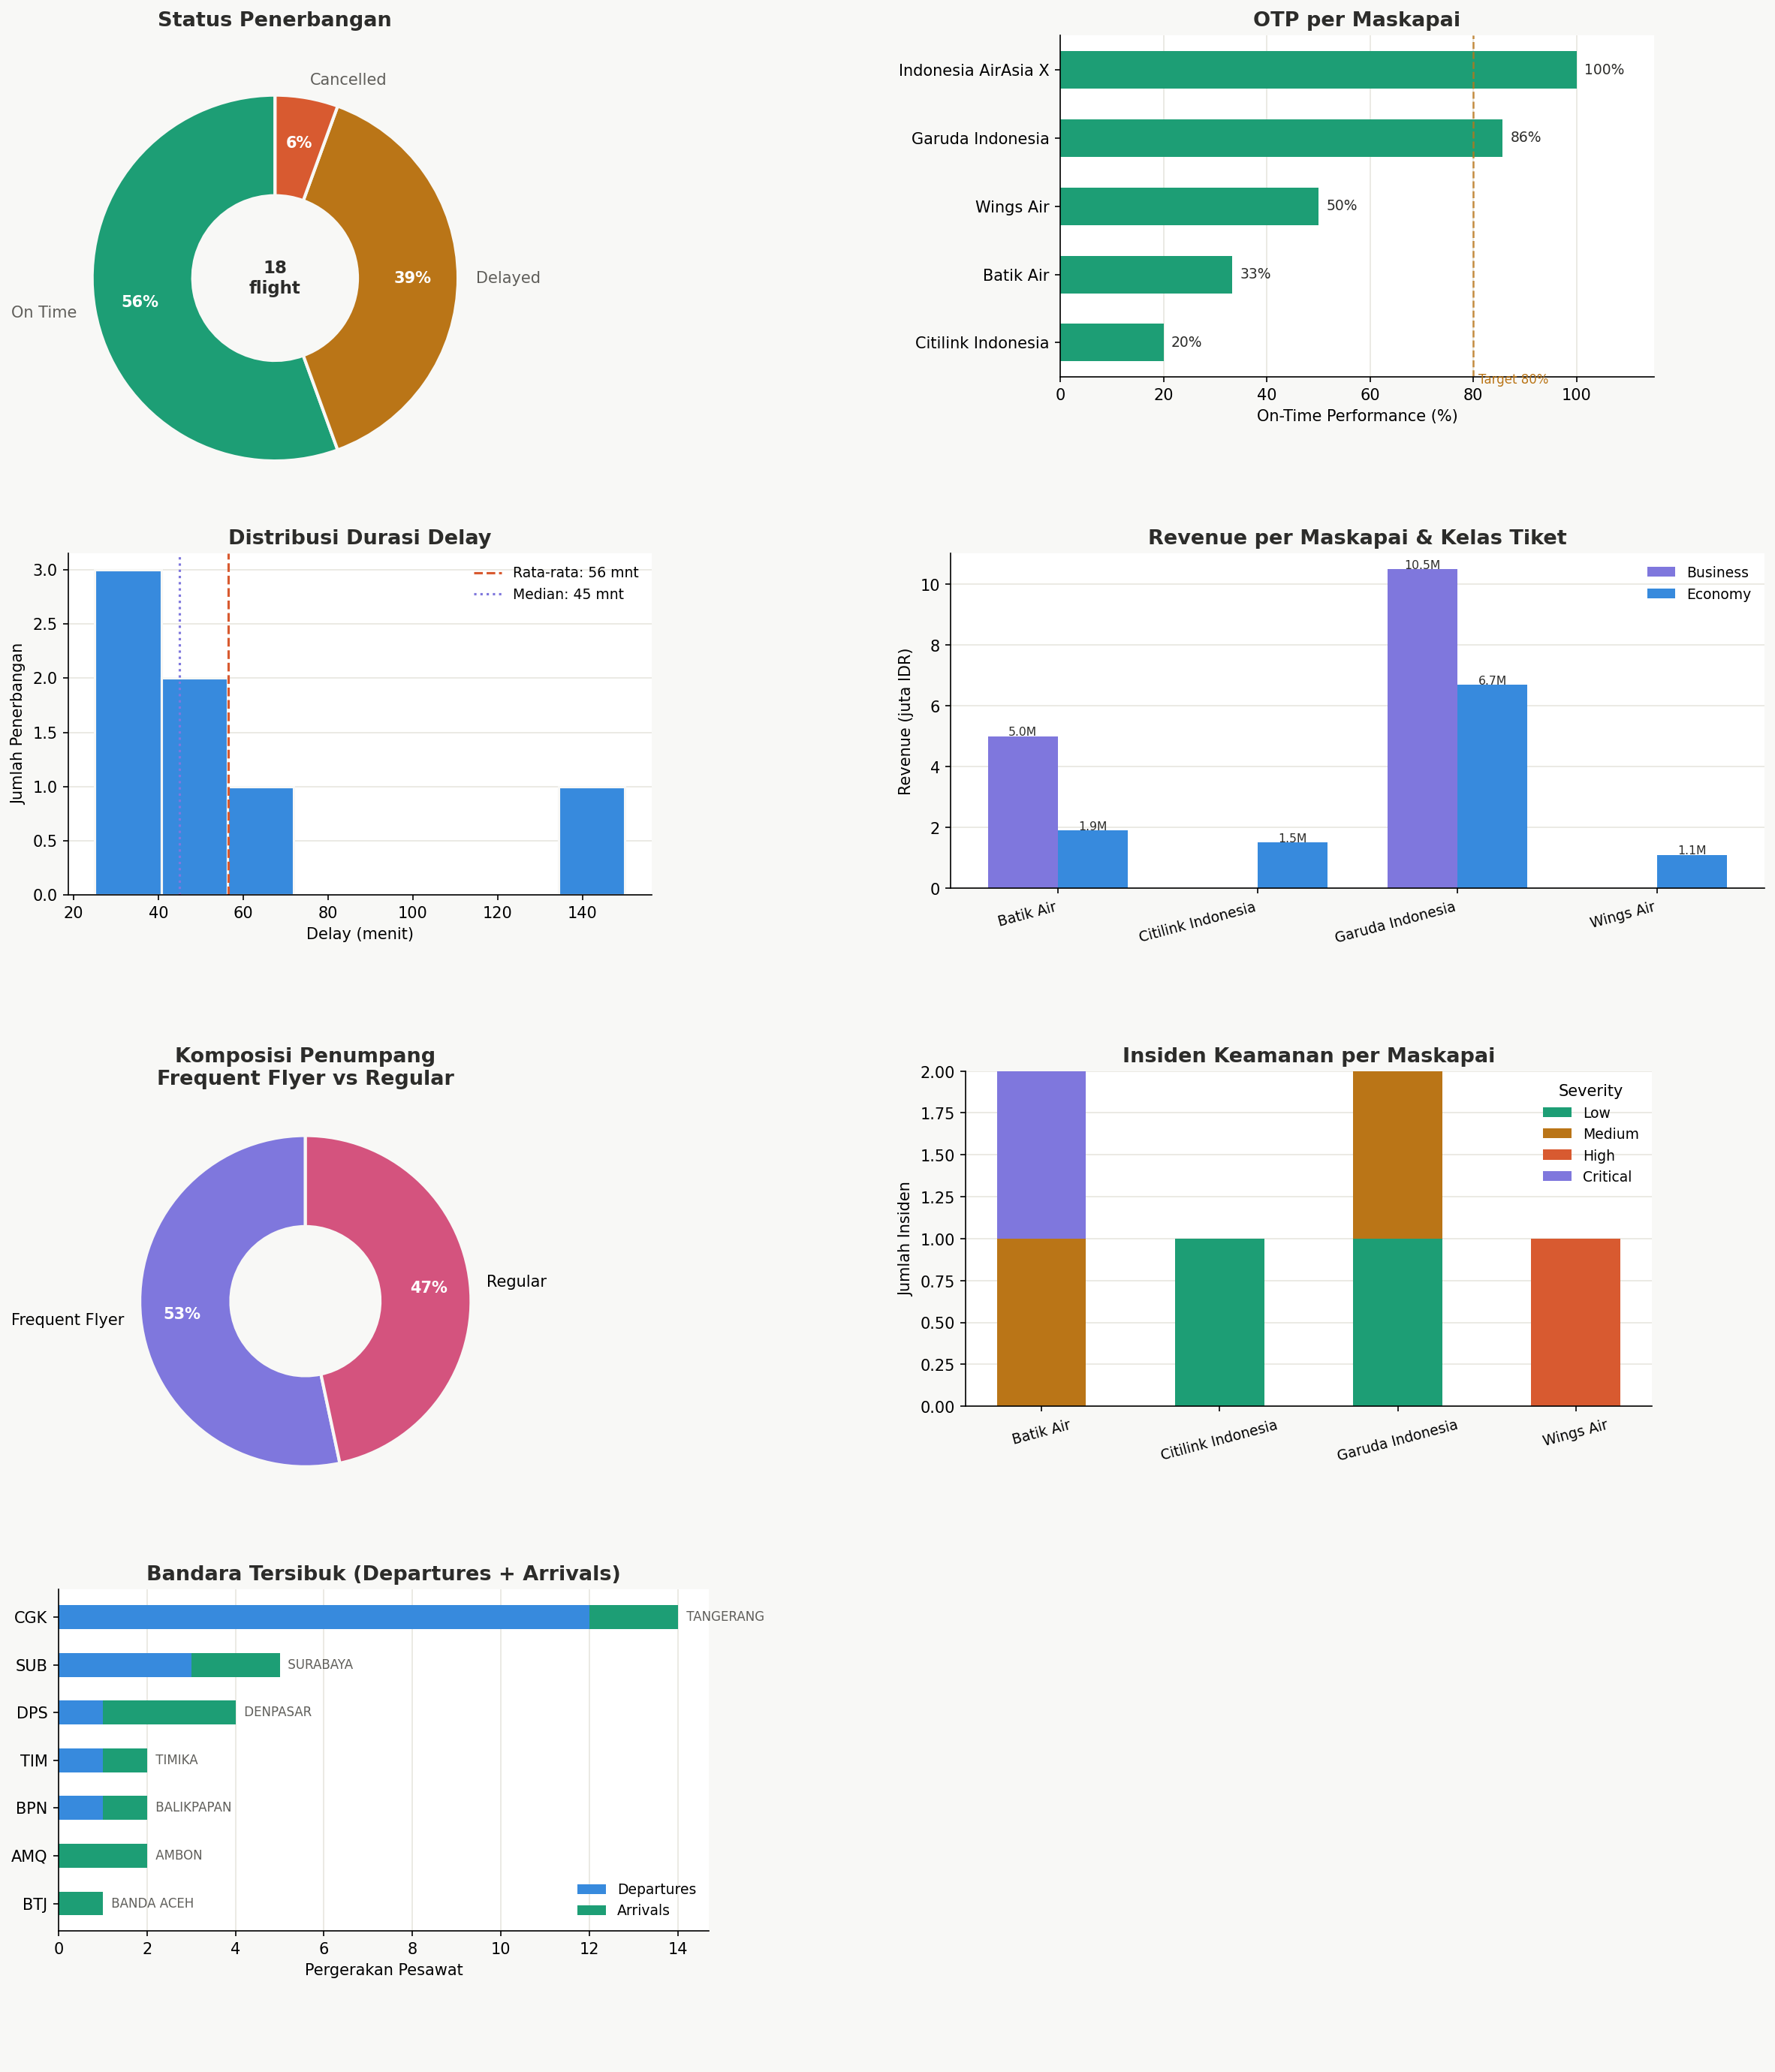

In [ ]:
import subprocess, sys

# Gabungkan semua chart yang sudah disimpan ke 1 figure
chart_files = [f'chart{i}_{n}.png' for i, n in
               enumerate(['status','otp','delay_dist','revenue','ff','incidents','airports'], 1)]

existing = [f for f in chart_files if os.path.exists(f)]
if existing:
    from PIL import Image
    imgs = [Image.open(f) for f in existing]

    # 2 kolom layout
    cols = 2
    rows = (len(imgs) + 1) // cols
    max_w = max(i.width  for i in imgs)
    max_h = max(i.height for i in imgs)

    canvas = Image.new('RGB', (max_w * cols, max_h * rows), (248, 248, 246))
    for idx, img in enumerate(imgs):
        r, c = divmod(idx, cols)
        canvas.paste(img, (c * max_w, r * max_h))

    canvas.save('aviation_dashboard.png')
    print('Dashboard disimpan ke aviation_dashboard.png')
    
    from IPython.display import Image as IPImage, display
    display(IPImage('aviation_dashboard.png', width=900))
else:
    print('Jalankan dulu semua cell chart di atas!')